# Notebook 04 — Preprocesado y Split
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 4 — Preprocesado Formal**

Prepara los arrays que recibirán todos los modelos. Regla de oro:
**ninguna información del test se usa antes de la evaluación final.**

Contenido:
- 4.1 Carga y definición de grupos de features
- 4.2 Split estratificado 80/20
- 4.3 Verificación de distribución train vs test
- 4.4 ColumnTransformer (ajuste exclusivo sobre train)
- 4.5 Class weight y scale_pos_weight
- 4.6 Visualización PCA — separabilidad en el espacio transformado
- 4.7 Verificaciones finales y guardado de artefactos

**Carga:** `data/processed/df_engineered.parquet`
**Genera:** arrays `.npy`, preprocessor `.joblib`, `meta.json`

---
## Setup

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE    = 0.20
ROOT         = os.path.abspath('..')
DATA_PROC    = os.path.join(ROOT, 'data', 'processed')
OUT_FIGS     = os.path.join(ROOT, 'outputs', 'figures')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

df = pd.read_parquet(os.path.join(DATA_PROC, 'df_engineered.parquet'))
print(f"Dataset cargado: {df.shape[0]:,} pacientes x {df.shape[1]} variables")

Dataset cargado: 50,001 pacientes x 40 variables


---
## 4.1 Definición de grupos de features

Clasificamos cada columna en su grupo de preprocesado y documentamos
las exclusiones finales con su justificación.

In [3]:
# ── Exclusiones finales ───────────────────────────────────────────────────────
EXCLUDE = [
    'paciente_id',   # identificador, no informativo
    'cancer',        # target
]

# ── Grupos de features ────────────────────────────────────────────────────────
NUMERIC_COLS = [
    # Bioquímica continua
    'glucosa', 'colesterol', 'trigliceridos', 'hemoglobina',
    'leucocitos', 'plaquetas', 'creatinina',
    # Sociodemografía continua
    'edad', 'num_hijos', 'distancia_hospital_km',
    # Features construidas continuas/ordinales
    'n_mutaciones', 'n_comorbilidades', 'weighted_mut_burden',
    'actividad_fisica_ord', 'edad_bin', 'edad_x_fumador',
]

BINARY_COLS = [
    # Clínica binaria
    'diabetes', 'hipertension', 'obesidad', 'enfermedad_cardiaca', 'asma', 'epoc',
    # Hábitos
    'fumador',
    # Genética (ya en 0/1, escalar no aporta)
    'mut_BRCA1', 'mut_TP53', 'mut_EGFR', 'mut_KRAS', 'mut_PIK3CA', 'mut_BRAF',
    # Umbrales bioquímicos
    'glucosa_alta', 'hemoglobina_baja', 'leucocitos_alto',
    # Interacciones binarias
    'fumador_x_obesidad', 'BRCA1_x_TP53',
]

CATEG_COLS = [
    'nivel_educativo', 'nivel_ingresos', 'zona', 'estado_civil',
]

all_feature_cols = NUMERIC_COLS + BINARY_COLS + CATEG_COLS

# Verificar que no falta ninguna columna del dataset
cols_in_df = set(df.columns) - set(EXCLUDE)
cols_defined = set(all_feature_cols)
not_assigned = cols_in_df - cols_defined
if not_assigned:
    print(f"AVISO — columnas sin asignar: {not_assigned}")
else:
    print("Todas las columnas asignadas correctamente.")

print(f"\nFeatures totales: {len(all_feature_cols)}")
print(f"  Numericas:   {len(NUMERIC_COLS)}")
print(f"  Binarias:    {len(BINARY_COLS)}")
print(f"  Categoricas: {len(CATEG_COLS)}")

Todas las columnas asignadas correctamente.

Features totales: 38
  Numericas:   16
  Binarias:    18
  Categoricas: 4


---
## 4.2 Split estratificado 80/20

Primera y única operación de división. El conjunto de test queda sellado
y no se vuelve a usar hasta la evaluación final.

In [4]:
X = df[all_feature_cols].copy()
y = df['cancer'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Verificación de estratificación
diff_prev = abs(y_train.mean() - y_test.mean())
assert diff_prev < 0.005, f"Split no estratificado: diff={diff_prev:.4f}"

print(f"Train: {len(X_train):,} pacientes  |  prevalencia cancer = {y_train.mean():.4f}")
print(f"Test:  {len(X_test):,}  pacientes  |  prevalencia cancer = {y_test.mean():.4f}")
print(f"Diferencia de prevalencia: {diff_prev:.5f}  (< 0.005 OK)")

Train: 40,000 pacientes  |  prevalencia cancer = 0.1929
Test:  10,001  pacientes  |  prevalencia cancer = 0.1929
Diferencia de prevalencia: 0.00001  (< 0.005 OK)


---
## 4.3 Verificación de distribución train vs test

Comprobamos que las features más importantes tienen distribuciones
comparables en ambos conjuntos. Un split desequilibrado en features clave
provocaría resultados optimistas o pesimistas en test.

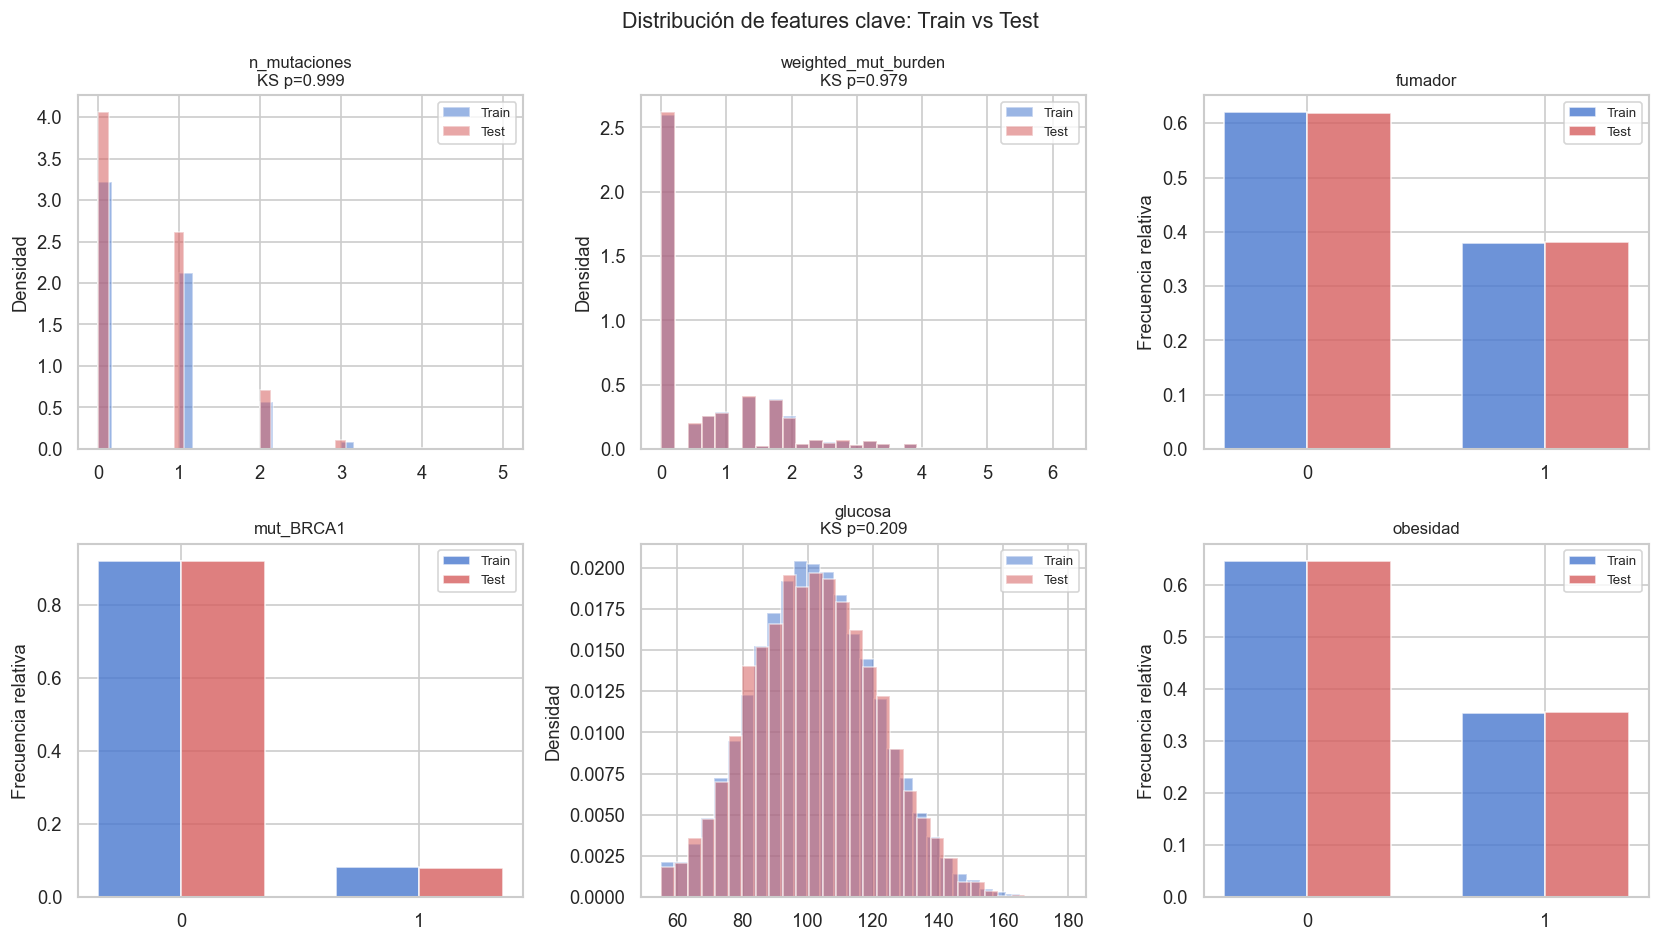

KS p > 0.05 en todas las features continuas indica distribuciones comparables.


In [5]:
from scipy import stats

KEY_FEATURES = ['n_mutaciones', 'weighted_mut_burden', 'fumador',
                'mut_BRCA1', 'glucosa', 'obesidad']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, feat in zip(axes, KEY_FEATURES):
    is_binary = X_train[feat].nunique() <= 5

    if is_binary:
        vals = sorted(X_train[feat].unique())
        x = np.arange(len(vals))
        w = 0.35
        train_freq = [X_train[feat].value_counts(normalize=True).get(v, 0) for v in vals]
        test_freq  = [X_test[feat].value_counts(normalize=True).get(v, 0)  for v in vals]
        ax.bar(x - w/2, train_freq, w, label='Train', color='#4878CF', alpha=0.8)
        ax.bar(x + w/2, test_freq,  w, label='Test',  color='#D65F5F', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in vals])
        ax.set_ylabel('Frecuencia relativa')
    else:
        ax.hist(X_train[feat], bins=30, alpha=0.55, density=True,
                color='#4878CF', label='Train')
        ax.hist(X_test[feat],  bins=30, alpha=0.55, density=True,
                color='#D65F5F', label='Test')
        ax.set_ylabel('Densidad')

    # KS test para distribuciones continuas
    if not is_binary:
        ks_stat, ks_p = stats.ks_2samp(X_train[feat], X_test[feat])
        ax.set_title(f'{feat}\nKS p={ks_p:.3f}', fontsize=10)
    else:
        ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Distribución de features clave: Train vs Test', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '11_train_test_distribution.png'), bbox_inches='tight')
plt.show()
print("KS p > 0.05 en todas las features continuas indica distribuciones comparables.")

---
## 4.4 ColumnTransformer

- `StandardScaler` → numéricas y ordinales construidas
- `passthrough` → binarias y genéticas (ya en 0/1)
- `OneHotEncoder` → categóricas sociodemográficas

**Ajuste exclusivo sobre X_train.** El test se transforma con los
estadísticos del train — nunca al revés.

In [6]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),
     NUMERIC_COLS),
    ('bin', 'passthrough',
     BINARY_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None),
     CATEG_COLS),
], remainder='drop')

# Ajuste SOLO en train
preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# Nombres de features tras el encoding
cat_names = (preprocessor
             .named_transformers_['cat']
             .get_feature_names_out(CATEG_COLS)
             .tolist())
FEATURE_NAMES = NUMERIC_COLS + BINARY_COLS + cat_names

print(f"Dimensiones tras preprocesado:")
print(f"  X_train_t: {X_train_t.shape}")
print(f"  X_test_t:  {X_test_t.shape}")
print(f"  Features totales: {len(FEATURE_NAMES)}")
print(f"  (numéricas: {len(NUMERIC_COLS)}  binarias: {len(BINARY_COLS)}  OHE: {len(cat_names)})")
print(f"\nNulos tras transformación: {np.isnan(X_train_t).sum() + np.isnan(X_test_t).sum()}")

Dimensiones tras preprocesado:
  X_train_t: (40000, 49)
  X_test_t:  (10001, 49)
  Features totales: 49
  (numéricas: 16  binarias: 18  OHE: 15)

Nulos tras transformación: 0


---
## 4.5 Class weight y scale_pos_weight

Calculados a partir del train únicamente para gestionar el desbalance 4.19:1.

In [7]:
cw_arr = compute_class_weight('balanced',
                               classes=np.array([0, 1]),
                               y=y_train)
CLASS_WEIGHT_DICT  = {0: float(cw_arr[0]), 1: float(cw_arr[1])}
SCALE_POS_WEIGHT   = float((y_train == 0).sum() / (y_train == 1).sum())
SAMPLE_WEIGHT_TRAIN = np.where(y_train == 1,
                               CLASS_WEIGHT_DICT[1],
                               CLASS_WEIGHT_DICT[0])

print(f"class_weight_dict:  {CLASS_WEIGHT_DICT}")
print(f"scale_pos_weight:   {SCALE_POS_WEIGHT:.4f}  (para XGBoost)")
print(f"\nInterpretación: cada paciente con cancer=1 cuenta")
print(f"{CLASS_WEIGHT_DICT[1]:.2f}x mas que uno con cancer=0 durante el entrenamiento.")

class_weight_dict:  {0: 0.6194827319188477, 1: 2.592352559948153}
scale_pos_weight:   4.1847  (para XGBoost)

Interpretación: cada paciente con cancer=1 cuenta
2.59x mas que uno con cancer=0 durante el entrenamiento.


---
## 4.6 PCA 2D — separabilidad en el espacio transformado

¿Son las clases visualmente separables tras el preprocesado?
Esta proyección responde a la pregunta de viabilidad del enunciado
desde una perspectiva geométrica.

Varianza explicada: PC1=10.9%  PC2=9.8%  Total=20.7%


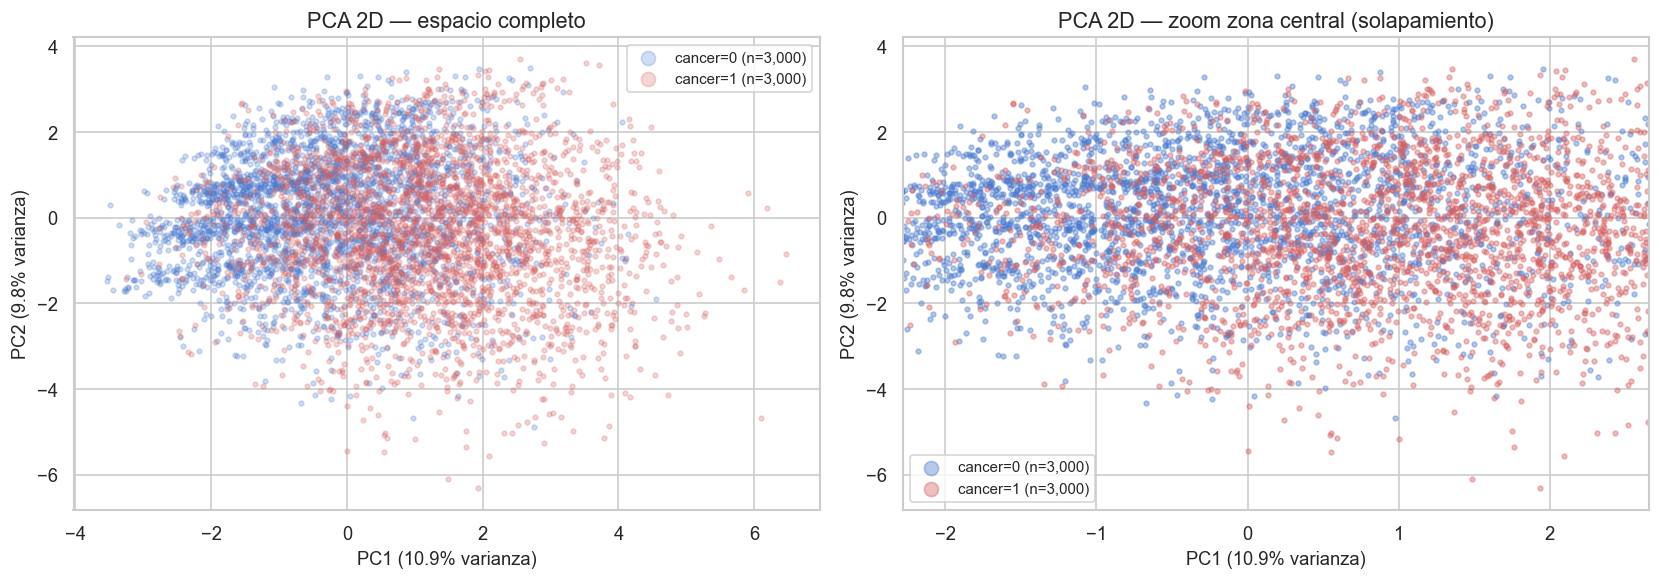


Top 10 features que definen PC1:
n_comorbilidades       0.418452
weighted_mut_burden    0.384864
n_mutaciones           0.377511
glucosa                0.361816
trigliceridos          0.344954
edad                   0.233390
edad_bin               0.230707
edad_x_fumador         0.212979
colesterol             0.167810
diabetes               0.144060


In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_t)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1={100*var_exp[0]:.1f}%  PC2={100*var_exp[1]:.1f}%"
      f"  Total={100*sum(var_exp):.1f}%")

# Muestra aleatoria para evitar overplotting
np.random.seed(RANDOM_STATE)
idx0 = np.where(y_train == 0)[0]
idx1 = np.where(y_train == 1)[0]
sample0 = np.random.choice(idx0, size=min(3000, len(idx0)), replace=False)
sample1 = np.random.choice(idx1, size=min(3000, len(idx1)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
for ax_idx, ax in enumerate(axes):
    alpha = 0.25 if ax_idx == 0 else 0.4
    ax.scatter(X_train_pca[sample0, 0], X_train_pca[sample0, 1],
               c='#4878CF', alpha=alpha, s=8, label=f'cancer=0 (n={len(sample0):,})')
    ax.scatter(X_train_pca[sample1, 0], X_train_pca[sample1, 1],
               c='#D65F5F', alpha=alpha, s=8, label=f'cancer=1 (n={len(sample1):,})')
    ax.set_xlabel(f'PC1 ({100*var_exp[0]:.1f}% varianza)')
    ax.set_ylabel(f'PC2 ({100*var_exp[1]:.1f}% varianza)')
    ax.legend(fontsize=9, markerscale=3)
    if ax_idx == 0:
        ax.set_title('PCA 2D — espacio completo')
    else:
        # Zoom en la zona de mayor solapamiento
        p5, p95 = np.percentile(X_train_pca[:, 0], [5, 95])
        ax.set_xlim(p5, p95)
        ax.set_title('PCA 2D — zoom zona central (solapamiento)')

# Loadings: top features que definen PC1
loadings = pd.Series(np.abs(pca.components_[0]),
                     index=FEATURE_NAMES).sort_values(ascending=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '12_pca_separability.png'), bbox_inches='tight')
plt.show()

print(f"\nTop 10 features que definen PC1:")
print(loadings.head(10).to_string())

In [9]:
# Interpretación de la separabilidad
overlap_zone = ((X_train_pca[:, 0] > np.percentile(X_train_pca[:, 0], 25)) &
                (X_train_pca[:, 0] < np.percentile(X_train_pca[:, 0], 75)))

prev_overlap = y_train.values[overlap_zone].mean()
prev_global  = y_train.mean()

print("Interpretacion del PCA:")
print(f"  Prevalencia global:          {100*prev_global:.1f}%")
print(f"  Prevalencia en zona central: {100*prev_overlap:.1f}%")
print()
print("Las clases se solapan significativamente en el espacio PCA.")
print("Esto es consistente con un Oracle AUC de 0.83 (no 1.0):")
print("existe senyal real, pero el ruido biologico del dataset hace")
print("que la separacion perfecta sea imposible por diseno.")

Interpretacion del PCA:
  Prevalencia global:          19.3%
  Prevalencia en zona central: 14.8%

Las clases se solapan significativamente en el espacio PCA.
Esto es consistente con un Oracle AUC de 0.83 (no 1.0):
existe senyal real, pero el ruido biologico del dataset hace
que la separacion perfecta sea imposible por diseno.


---
## 4.7 Verificaciones finales y guardado de artefactos

El `meta.json` centraliza todos los parámetros que necesitarán los notebooks
de modelos, evitando recalcularlos y garantizando consistencia.

In [ ]:
# ── Verificaciones finales ────────────────────────────────────────────────────
assert X_train_t.shape[0] == len(y_train), "Shape mismatch train"
assert X_test_t.shape[0]  == len(y_test),  "Shape mismatch test"
assert X_train_t.shape[1] == X_test_t.shape[1], "Numero de features distinto"
assert np.isnan(X_train_t).sum() == 0, "NaN en X_train_t"
assert np.isnan(X_test_t).sum()  == 0, "NaN en X_test_t"
print("Todas las verificaciones pasadas.")

# ── Guardado de arrays ────────────────────────────────────────────────────────
np.save(os.path.join(DATA_PROC, 'X_train.npy'),   X_train_t)
np.save(os.path.join(DATA_PROC, 'X_test.npy'),    X_test_t)
np.save(os.path.join(DATA_PROC, 'y_train.npy'),   y_train.values)
np.save(os.path.join(DATA_PROC, 'y_test.npy'),    y_test.values)

# Arrays sin escalar para SHAP (modelos de árbol no necesitan escalado)
X_train.to_parquet(os.path.join(DATA_PROC, 'X_train_raw.parquet'))
X_test.to_parquet(os.path.join(DATA_PROC, 'X_test_raw.parquet'))

# Preprocessor y indices
joblib.dump(preprocessor, os.path.join(DATA_PROC, 'preprocessor.joblib'))
np.save(os.path.join(DATA_PROC, 'test_index.npy'), X_test.index.values)

# meta.json — parametros centralizados para los notebooks de modelos
meta = {
    'n_features':        int(X_train_t.shape[1]),
    'n_train':           int(X_train_t.shape[0]),
    'n_test':            int(X_test_t.shape[0]),
    'prevalence_train':  float(y_train.mean()),
    'prevalence_test':   float(y_test.mean()),
    'class_weight':      CLASS_WEIGHT_DICT,
    'scale_pos_weight':  SCALE_POS_WEIGHT,
    'feature_names':     FEATURE_NAMES,
    'numeric_cols':      NUMERIC_COLS,
    'binary_cols':       BINARY_COLS,
    'categ_cols':        CATEG_COLS,
    'random_state':      RANDOM_STATE,
    'oracle_auc':        0.8335,
}

with open(os.path.join(DATA_PROC, 'meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print()
print("Artefactos guardados:")
for fname in ['X_train.npy','X_test.npy','y_train.npy','y_test.npy',
              'X_train_raw.parquet','X_test_raw.parquet',
              'preprocessor.joblib','test_index.npy','meta.json']:
    fpath = os.path.join(DATA_PROC, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {fname:<30} {size:>8.1f} KB")

print()
print("Listo para Notebook 05 — Modelos Clasicos")

Todas las verificaciones pasadas.

Artefactos guardados:
  X_train.npy                     15312.6 KB
  X_test.npy                       3828.6 KB
  y_train.npy                       312.6 KB
  y_test.npy                         78.3 KB
  X_train_raw.parquet              1284.2 KB
  X_test_raw.parquet                399.7 KB
  preprocessor.joblib                 5.5 KB
  test_index.npy                     78.3 KB
  meta.json                           2.3 KB

Listo para Notebook 05 — Modelos Clasicos


: 